# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
#Type your code here
import os
import shutil
import numpy as np
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from PIL import Image
from skimage.transform import rotate
from skimage.exposure import adjust_gamma
from skimage import io
from skimage.util import img_as_ubyte
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm as tq

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anwhil","key":"0bb9a213ac59d3711c38581b7b553d08"}'}

In [5]:
#Type your code here
!kaggle datasets download -d antobenedetti/animals
!unzip animals.zip

# Direktori awal untuk train dan test
train_dir = "animals/train"
val_dir = "animals/val"

# Direktori baru untuk dataset gabungan
combined_dir = "animals/dataset"

# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari val
for category in os.listdir(val_dir):
    category_dir = os.path.join(val_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_image = {}

# Tentukan path sumber train
path = "animals/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Definisikan path sumber
lung_path = "animals/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

Streaming output truncated to the last 5000 lines.
  inflating: animals/train/horse/horse2690.jpg  
  inflating: animals/train/horse/horse2691.jpg  
  inflating: animals/train/horse/horse2692.jpg  
  inflating: animals/train/horse/horse2693.jpg  
  inflating: animals/train/horse/horse2694.jpg  
  inflating: animals/train/horse/horse2695.jpg  
  inflating: animals/train/horse/horse2696.jpg  
  inflating: animals/train/horse/horse2697.jpg  
  inflating: animals/train/horse/horse2698.jpg  
  inflating: animals/train/horse/horse2699.jpg  
  inflating: animals/train/horse/horse27.jpg  
  inflating: animals/train/horse/horse270.jpg  
  inflating: animals/train/horse/horse2701.jpg  
  inflating: animals/train/horse/horse2702.jpg  
  inflating: animals/train/horse/horse2703.jpg  
  inflating: animals/train/horse/horse2704.jpg  
  inflating: animals/train/horse/horse2705.jpg  
  inflating: animals/train/horse/horse2706.jpg  
  inflating: animals/train/horse/horse2707.jpg  
  inflating: animals/

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

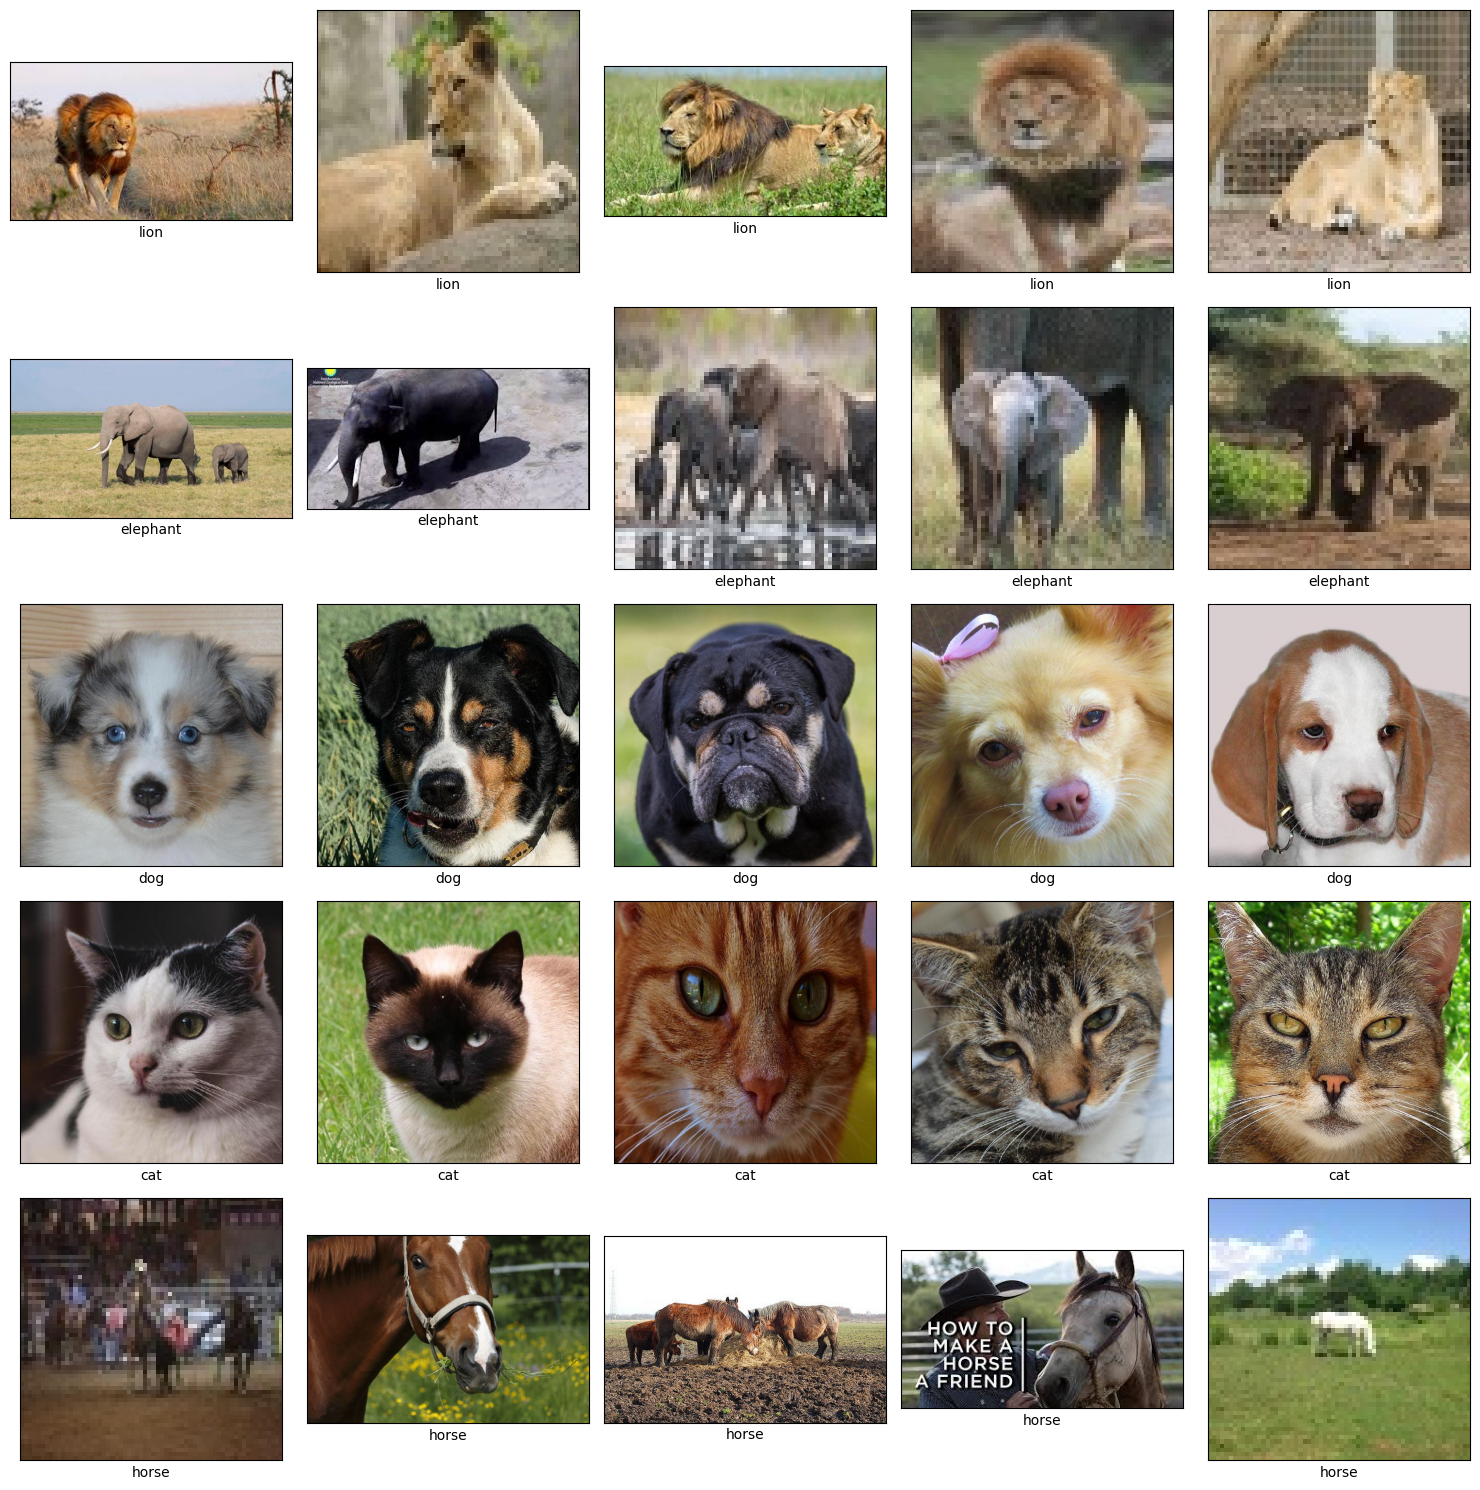

In [6]:
#Type your code here
# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("RGB")
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

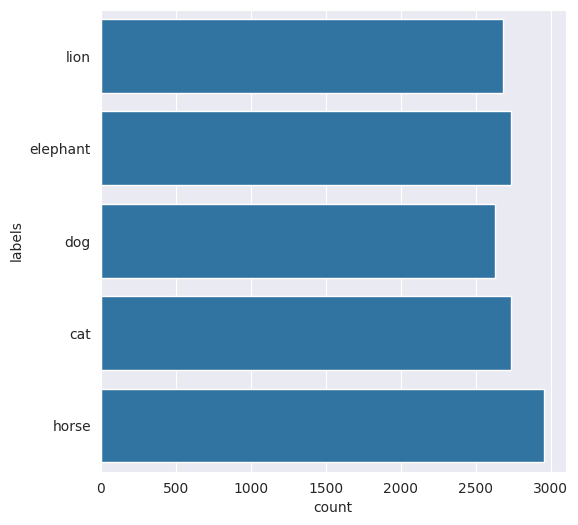

In [7]:
# Plot distribusi gambar di setiap kelas
distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
def resize_img(img):
    return cv2.resize(img, (150, 150))

def subtle_rotation(img):
    img = resize_img(img)
    sudut = random.randint(-30, 30)
    return rotate(img, sudut, preserve_range=True)

def flip_left_right(img):
    img = resize_img(img)
    return np.fliplr(img)

def blur_image(img):
    img = resize_img(img)
    return cv2.GaussianBlur(img, (5, 5), 0)

def add_brightness(img):
    img = resize_img(img)
    gamma_val = random.uniform(0.7, 1.3)
    return adjust_gamma(img, gamma=gamma_val, preserve_range=True)

def enhance_contrast(img):
    img = resize_img(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

In [9]:
transformations = {
    'subtle rotation': subtle_rotation,
    'blurring image': blur_image,
    'add brightness': add_brightness,
    'flip horizontal': flip_left_right,
    'resize_img': resize_img,
    'enhace_contrast': enhance_contrast
}

base_path = "animals/dataset/"
target_folders = os.listdir(base_path)[:5]

# 2. Loop untuk setiap folder
for idx, folder in enumerate(target_folders):
    images_path = os.path.join(base_path, folder)
    augmented_path = images_path

    images = [os.path.join(images_path, im) for im in os.listdir(images_path) if im.endswith(('.jpg', '.png', '.jpeg'))]

    # 3. Tentukan jumlah tambahan gambar
    target_total = 4000
    current_count = len(images)
    images_to_generate = target_total - current_count

    i = 1
    print(f"Memproses {folder}: Butuh {max(0, images_to_generate)} gambar tambahan.")

    # 4. Proses pembuatan gambar augmentasi (DIMASUKKAN KE DALAM INDENTASI LOOP FOR)
    while i <= images_to_generate:
        image_path = random.choice(images)
        try:
            original_image = io.imread(image_path)

            if len(original_image.shape) == 2:
                original_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB)
            elif original_image.shape[2] == 4:
                original_image = cv2.cvtColor(original_image, cv2.COLOR_RGBA2RGB)

            transformed_image = original_image

            transformation_count = random.randint(1, 3)
            for _ in range(transformation_count):
                key = random.choice(list(transformations))
                transformed_image = transformations[key](transformed_image)

            new_image_path = os.path.join(augmented_path, f"aug_{folder}_{i}.jpg")
            transformed_image = img_as_ubyte(transformed_image)

            cv2.imwrite(new_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))
            i += 1
        except Exception as e:
            print(f'Gagal memproses {image_path}: {e}')

Streaming output truncated to the last 5000 lines.
Gagal memproses animals/dataset/dog/dog2410.jpg: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<3, 4>; VDcn = cv::impl::{anonymous}::Set<3>; VDepth = cv::impl::{anonymous}::Set<0, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 6 (CV_64F)

Gagal memproses animals/dataset/dog/dog750.jpg: adjust_gamma() got an unexpected keyword argument 'preserve_range'
Gagal memproses animals/dataset/dog/dog2245.jpg: adjust_gamma() got an unexpected keyword argument 'preserve_range'
Gagal memproses animals/dataset/dog/dog282.jpg:

In [10]:
# Definisikan path sumber
base_path = "animals/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label (hanya untuk 5 folder pertama seperti di atas)
target_folders = os.listdir(base_path)[:5]

for folder in target_folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        for name in os.listdir(folder_path):
            if name.endswith(('.jpg', '.png', '.jpeg')):
                full_path.append(os.path.join(folder_path, name))
                labels.append(folder)
                file_name.append(name)

In [11]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'animals/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
cat,4000
dog,4000
elephant,4000
horse,4000
lion,4000


In [12]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels
from sklearn.model_selection import train_test_split
X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "animals/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels  
test   cat          811
       dog          815
       elephant     805
       horse        818
       lion         751
train  cat         3189
       dog         3185
       elephant    3195
       horse       3182
       lion        3249
dtype: int64 


                                            path    labels    set
8165     animals/dataset/horse/aug_horse_385.jpg     horse  train
19645    animals/dataset/horse/aug_horse_558.jpg     horse   test
17379    animals/dataset/horse/aug_horse_682.jpg     horse   test
18144  animals/dataset/elephant/elephant2063.jpg  elephant   test
11629        animals/dataset/cat/aug_cat_151.jpg       cat  train


In [13]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [14]:
!zip -r hasil_folder.zip /content/Dataset-Final/

Streaming output truncated to the last 5000 lines.
  adding: content/Dataset-Final/train/horse/horse873.jpg (deflated 2%)
  adding: content/Dataset-Final/train/horse/aug_horse_246.jpg (deflated 2%)
  adding: content/Dataset-Final/train/horse/horse453.jpg (deflated 1%)
  adding: content/Dataset-Final/train/horse/horse2086.jpg (deflated 1%)
  adding: content/Dataset-Final/train/horse/aug_horse_502.jpg (deflated 1%)
  adding: content/Dataset-Final/train/horse/horse277.jpg (deflated 5%)
  adding: content/Dataset-Final/train/horse/aug_horse_877.jpg (deflated 1%)
  adding: content/Dataset-Final/train/horse/aug_horse_418.jpg (deflated 2%)
  adding: content/Dataset-Final/train/horse/horse2000.jpg (deflated 5%)
  adding: content/Dataset-Final/train/horse/horse1249.jpg (deflated 6%)
  adding: content/Dataset-Final/train/horse/aug_horse_608.jpg (deflated 1%)
  adding: content/Dataset-Final/train/horse/aug_horse_377.jpg (deflated 2%)
  adding: content/Dataset-Final/train/horse/aug_horse_683.jpg (d